# Hub & Spoke Thermal Shimming

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors
import serial
import serial.tools.list_ports
import time

In [2]:
def plot_disk(temps, ax, norm):
    rect_width = 0.08
    rect_height = 0.4
    mag_dia = 0.8
    values_normalized = norm(temps)
    cmap = plt.get_cmap('coolwarm')
    for i in range(32):
        r = plt.Rectangle((-rect_width/2,mag_dia-rect_height/2), 
                          rect_width, rect_height, color=cmap(values_normalized[i]))
        t2 = matplotlib.transforms.Affine2D().rotate(i/32*2*np.pi) + ax.transData
        r.set_transform(t2)
        ax.add_patch(r)
    ax.set_xlim(-1,1)
    ax.set_ylim(-1,1)
    ax.set_aspect(1)
    ax.axis('off')

def plot_magnet_temp(axs, temps):
    norm = matplotlib.colors.Normalize(vmin=np.nanmin(temps), vmax=np.nanmax(temps))
    plot_disk(temps[:32], ax[0], norm)
    plot_disk(temps[32:], ax[1], norm)

In [3]:
def get_temps():
    ser.write('rt\n'.encode('utf-8'))
    temp_bytes = ser.read(4*64)
    temps = np.frombuffer(temp_bytes, dtype=np.uint32)
    return temps

In [18]:
#Autodetect COM port
class AutoDetectException(Exception):
    pass

ports = serial.tools.list_ports.comports(include_links=False)
comport = ''
for port in ports:
    if port.pid == 14164:
        comport = port.device
        print("Connected to " + port.device)
        break
if comport == '':
    raise AutoDetectException("Port AutoDetect Failed")
    
ser = serial.Serial(comport, timeout=4, baudrate=115200)
ser.reset_input_buffer()

Connected to COM5


In [17]:
ser.close()

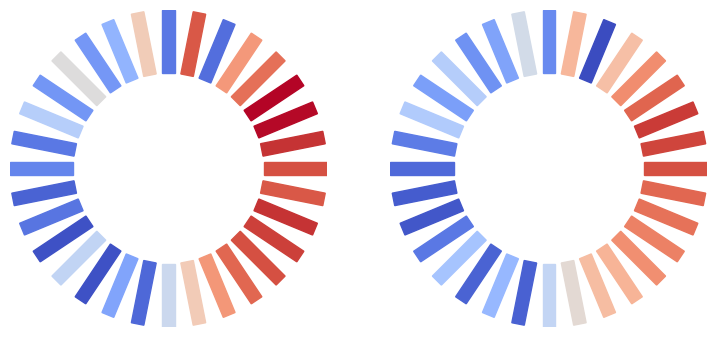

ValueError: zero-size array to reduction operation fmin which has no identity

In [26]:
magfig, ax = plt.subplots(1,2, figsize=(9, 5))
hfig = display(magfig, display_id=True)
while(1):
    temps = get_temps()

    [axn.cla() for axn in ax]
    plt.close(magfig)
    plot_magnet_temp(ax, temps)
    magfig.canvas.draw()
    hfig.update(magfig)
    time.sleep(1)